# DETECCION DE FALLAS EN MAQUINA
# DATASET AI4I 200O PREDICTIVE MAINTENANCE

Importamos librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Cargamos los datos desde el equipo

In [2]:
from google.colab import files
uploaded = files.upload()


Saving ai 2020.csv to ai 2020.csv


Lectura del dataset

In [3]:
df = pd.read_csv('ai 2020.csv')
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


Estadísticas Descriptivas

In [40]:
print (df.describe())

               UDI  Air temperature [K]  Process temperature [K]  \
count  10000.00000         10000.000000             10000.000000   
mean    5000.50000           300.004930               310.005560   
std     2886.89568             2.000259                 1.483734   
min        1.00000           295.300000               305.700000   
25%     2500.75000           298.300000               308.800000   
50%     5000.50000           300.100000               310.100000   
75%     7500.25000           301.500000               311.100000   
max    10000.00000           304.500000               313.800000   

       Rotational speed [rpm]   Torque [Nm]  Tool wear [min]  Machine failure  \
count            10000.000000  10000.000000     10000.000000     10000.000000   
mean              1538.776100     39.986910       107.951000         0.033900   
std                179.284096      9.968934        63.654147         0.180981   
min               1168.000000      3.800000         0.000000   

Info del DataFrame

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

corroboramos que no tenga datos nulos

In [6]:
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


Valores Duplicados

In [7]:
df.duplicated().sum()

np.int64(0)

Distribucion de la variable objetivo

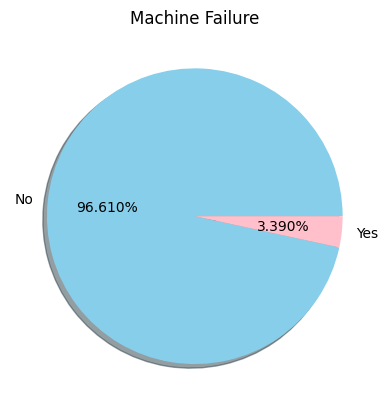

In [8]:
plt.pie(x = df['Machine failure'].value_counts(), autopct='%1.3f%%', labels=['No','Yes'], colors=['skyblue','pink'], shadow=True)
plt.title('Machine Failure-Dataset original')
plt.show()

Separacion de datos

In [9]:
x = df.drop(['UDI','Product ID', 'Type', 'Machine failure','TWF', 'HDF', 'PWF', 'OSF', 'RNF'], axis=1)
y = df['Machine failure']

In [41]:
print("Features:")
print(x.head())
print("\nTarget:")
print(y.head())

Features:
   Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0                298.1                    308.6                    1551   
1                298.2                    308.7                    1408   
2                298.1                    308.5                    1498   
3                298.2                    308.6                    1433   
4                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  
0         42.8                0  
1         46.3                3  
2         49.4                5  
3         39.5                7  
4         40.0                9  

Target:
0    0
1    0
2    0
3    0
4    0
Name: Machine failure, dtype: int64


Importacion de librerias

In [12]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier

Modelo 1: Random Forest

In [13]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20,random_state=42)

#escalamos los datos
scaler= StandardScaler()
x_train_scaled= scaler.fit_transform(x_train)
x_test_scaled= scaler.transform(x_test)
y_test_original = y_test.copy()  # guardamos para comparar después

Entrenamiento

In [14]:
rf_original= RandomForestClassifier(n_estimators=100,random_state=42)
rf_original.fit(x_train_scaled ,y_train)

RandomForestClassifier(random_state=42)

Evaluacion del Modelo

In [15]:
y_pred= rf_original.predict(x_test_scaled)
print('Reporte de clasificacion:\n', classification_report(y_test,y_pred))
y_prob_original = rf_original.predict_proba(x_test_scaled)[:, 1]

Reporte de clasificacion:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      1939
           1       0.80      0.59      0.68        61

    accuracy                           0.98      2000
   macro avg       0.89      0.79      0.84      2000
weighted avg       0.98      0.98      0.98      2000



Matriz de confusion

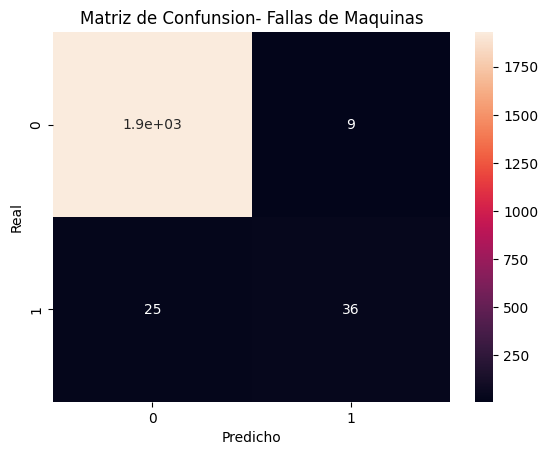

In [16]:
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión- Fallas de Maquinas')
plt.show()

# SMOTE Balanceo de clases

Importamos librerias

In [18]:
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier

Aplicamos el SMOTE

In [42]:
oversample = SMOTE(k_neighbors=5, random_state=43)

In [43]:
x_feacture_smoted, y_target_smoted = oversample.fit_resample(x, y)
y_target_smoted = pd.Series(y_target_smoted)

In [44]:
print(f'datos antes del SMOTE\n{y.value_counts()}\n')
print(f'datos despues de aplicar SMOTE\n{y_target_smoted.value_counts()}')

datos antes del SMOTE
Machine failure
0    9661
1     339
Name: count, dtype: int64

datos despues de aplicar SMOTE
Machine failure
0    9661
1    9661
Name: count, dtype: int64


Distribución tras SMOTE

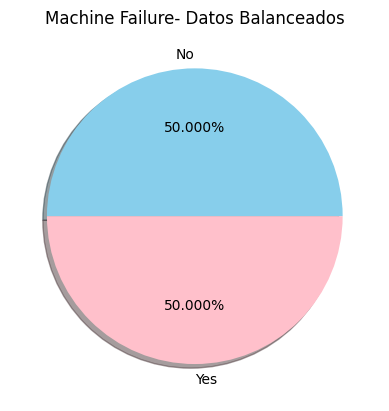

In [45]:
plt.pie(x = y_target_smoted.value_counts() ,autopct='%1.3f%%' ,labels=['No', 'Yes'], colors=['skyblue', 'pink'], shadow=True)
plt.title('Machine Failure- Datos Balanceados')
plt.show()

## Modelo 2: Random Forest con SMOTE

Separamos en feature / target

In [31]:
x_train , x_test, y_train, y_test = train_test_split (x_feacture_smoted,y_target_smoted, test_size=0.2,random_state = 44 )

Escalado

In [46]:
scaler_smote = StandardScaler()
X_train_scaled = scaler_smote.fit_transform(x_train)
X_test_scaled = scaler_smote.transform(x_test)

Entrenamiento

In [47]:
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

Evaluamos

In [48]:
y_pred_smote= rf_smote.predict(X_test_scaled)

Presicion

In [49]:
tr_accuracy = rf_smote.score(X_train_scaled, y_train)
ts_accuracy = accuracy_score(y_test, y_pred_smote)

print("Train Accuracy:", f'{round(tr_accuracy, 4) * 100:}%')
print("Test Accuracy:", f'{round(ts_accuracy, 4) * 100:}%')

Train Accuracy: 100.0%
Test Accuracy: 94.46%


Reporte de clasificacion

In [51]:
print("Classification Report:\n", classification_report(y_test, y_pred_smote))

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.94      0.94      1938
           1       0.94      0.95      0.94      1927

    accuracy                           0.94      3865
   macro avg       0.94      0.94      0.94      3865
weighted avg       0.94      0.94      0.94      3865



Matriz de confusion con SMOTE

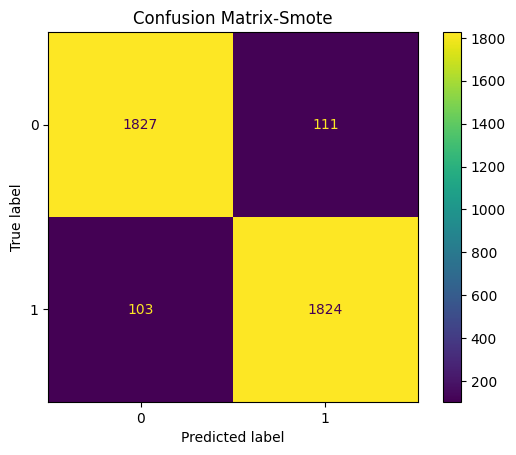

In [50]:
matrix_smote = confusion_matrix(y_test,y_pred_smote)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=matrix_smote)
disp.plot()
plt.title("Confusion Matrix-Smote")
plt.show()

## Curva ROC + AUC

Comparamos la curva ROC de ambos modelos. El AUC (Area Under the Curve) mide qué tan bien separa el modelo las clases: 1.0 es perfecto, 0.5 es aleatorio.

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probabilidades — modelo SMOTE
y_prob_smote = rf_smote.predict_proba(X_test_scaled)[:, 1]

# Curvas ROC
fpr1, tpr1, _ = roc_curve(y_test, y_prob_smote)
auc_smote     = roc_auc_score(y_test, y_prob_smote)

fpr0, tpr0, _ = roc_curve(y_test_original, y_prob_original)
auc_original  = roc_auc_score(y_test_original, y_prob_original)

plt.figure(figsize=(8, 5))
plt.plot(fpr0, tpr0, label=f'RF sin SMOTE (AUC = {auc_original:.3f})', color='steelblue')
plt.plot(fpr1, tpr1, label=f'RF con SMOTE  (AUC = {auc_smote:.3f})',   color='salmon')
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC — Comparación de Modelos')
plt.legend()
plt.tight_layout()
plt.show()

⚠️ **Nota:** para graficar la ROC del modelo sin SMOTE necesitamos el `y_test` que usamos en ese paso. Agregamos una celda que lo guarda con otro nombre justo después del split original.

## Importancia de Features

El Random Forest nos dice qué variables tuvieron más peso en las predicciones. Esto es muy útil para entender qué factores generan fallas en la máquina.

In [ ]:
feature_names = x.columns.tolist()
importances   = rf_smote.feature_importances_
indices       = importances.argsort()[::-1]

plt.figure(figsize=(8, 5))
sns.barplot(
    x=importances[indices],
    y=[feature_names[i] for i in indices],
    palette='viridis'
)
plt.title('Importancia de Features — Random Forest con SMOTE')
plt.xlabel('Importancia')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Tabla con los valores exactos
importance_df = pd.DataFrame({
    'Feature':    [feature_names[i] for i in indices],
    'Importancia': importances[indices].round(4)
})
print(importance_df.to_string(index=False))

## Modelo 3: XGBoost con SMOTE

Entrenamos XGBoost sobre los mismos datos balanceados para comparar con Random Forest.

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb  = xgb_model.predict(X_test_scaled)
y_prob_xgb  = xgb_model.predict_proba(X_test_scaled)[:, 1]
auc_xgb     = roc_auc_score(y_test, y_prob_xgb)

print('Reporte XGBoost:\n', classification_report(y_test, y_pred_xgb))
print(f'AUC XGBoost: {auc_xgb:.4f}')

## Comparación de Modelos

Resumen de las métricas clave de cada modelo para elegir el mejor.

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

def metricas(nombre, y_true, y_pred, y_prob):
    return {
        'Modelo':     nombre,
        'Accuracy':   round(accuracy_score(y_true, y_pred), 4),
        'Precision':  round(precision_score(y_true, y_pred), 4),
        'Recall':     round(recall_score(y_true, y_pred), 4),
        'F1-Score':   round(f1_score(y_true, y_pred), 4),
        'AUC':        round(roc_auc_score(y_true, y_prob), 4),
    }

resultados = pd.DataFrame([
    metricas('RF sin SMOTE',  y_test_original, y_pred,       y_prob_original),
    metricas('RF con SMOTE',  y_test,          y_pred_smote, y_prob_smote),
    metricas('XGBoost SMOTE', y_test,          y_pred_xgb,   y_prob_xgb),
])

print(resultados.to_string(index=False))

## Curva ROC — Los 3 Modelos

In [ ]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8, 5))
plt.plot(fpr0,     tpr0,     label=f'RF sin SMOTE  (AUC = {auc_original:.3f})', color='steelblue')
plt.plot(fpr1,     tpr1,     label=f'RF con SMOTE  (AUC = {auc_smote:.3f})',    color='salmon')
plt.plot(fpr_xgb,  tpr_xgb,  label=f'XGBoost SMOTE (AUC = {auc_xgb:.3f})',     color='seagreen')
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC — Comparación de los 3 Modelos')
plt.legend()
plt.tight_layout()
plt.show()